In [1]:
import pandas as pd  
df = pd.read_csv(r"C:\Users\bhagy\OneDrive\Desktop\practice\NewspaperData.csv")

In [2]:
df.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [3]:
df.isnull().sum()

Newspaper    0
daily        0
sunday       0
dtype: int64

In [4]:
# EDA
dff=df.dropna()
dff.isna().sum()

Newspaper    0
daily        0
sunday       0
dtype: int64

# ML model building
1. Data read 
2. Cleaning
3. EDA
4. Preprocessing
5. Data Spliting
6. Processing
7. Performance checking

In [5]:
# Find correlation
corr=df[['daily', 'sunday']].corr()

In [6]:
print(corr)

           daily    sunday
daily   1.000000  0.958154
sunday  0.958154  1.000000


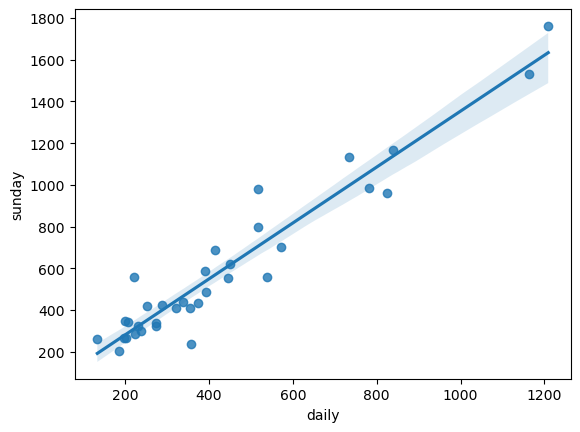

In [7]:
import seaborn as sns   
sns.regplot(x="daily",y="sunday",data=df);

<Axes: xlabel='daily', ylabel='Density'>

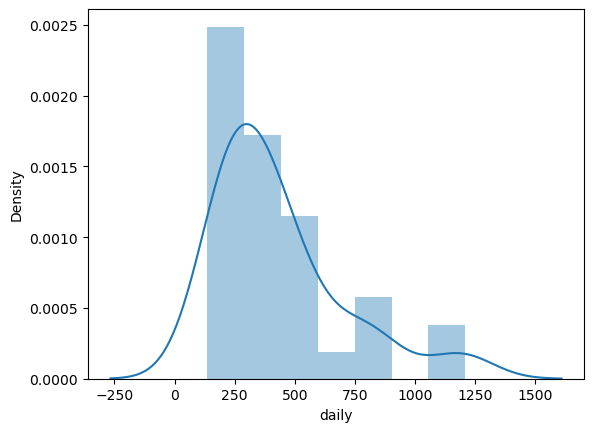

In [8]:
import seaborn as sns   
import warnings
warnings.filterwarnings('ignore')
sns.distplot(df['daily'])

In [9]:
dff.head(2)

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298


In [10]:
x=df.iloc[:,1]
y=df.iloc[:,-1]

X = df[['daily']]
y = df['sunday']

### Fitting a Linear Regression Model

In [12]:
# train model
from  sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X,y)

print("Intercept:",  lin_model.intercept_)
print("Slope:", lin_model.coef_)

#y_pred=lin_model.predict(X)

y_pred=lin_model.predict(X)
print(y_pred)


Intercept: 13.835629909636282
Slope: [1.33971476]
[ 538.93950861  706.44270505  490.27570976  333.43128393  734.3074323
  996.88482623  280.21379461  352.27973085  290.0901718   323.54686845
  616.37904075  400.43845725  262.66889014 1573.78341718  609.4473566
  566.96500163  378.61316413 1061.21926861 1633.85220777 1119.78623895
  313.59412751  489.22403367  704.48940094  309.19584396  466.21979157
  277.92020294  192.33788451  514.90100672  380.70847801  777.96069796
  538.04725858  284.2704509   444.72272856 1137.72501956]


In [13]:
y

0      488.506
1      798.298
2      235.084
3      299.451
4      559.093
5     1133.249
6      348.744
7      417.779
8      344.522
9      323.084
10     620.752
11     423.305
12     202.614
13    1531.527
14     553.479
15     685.975
16     324.241
17     983.240
18    1762.015
19     960.308
20     284.611
21     407.760
22     982.663
23     557.000
24     440.923
25     268.060
26     262.048
27     432.502
28     338.355
29     704.322
30     585.681
31     267.781
32     408.343
33    1165.567
Name: sunday, dtype: float64

In [15]:
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y,y_pred)

print("R2 Score:",r2)
print("Mean Square Error:",mse)
print("mean_absolute_error:",mae)

R2 Score: 0.9180596895873295
Mean Square Error: 11268.6920722415
mean_absolute_error: 80.1327444999346


In [16]:
# examplem prediction

daily_val = 516.9
predicted_sunday = lin_model.predict([[daily_val]])
print(f"Predicted Sunday circulation for daily={daily_val}: {predicted_sunday}")

Predicted Sunday circulation for daily=516.9: [706.33418816]


In [17]:
newdata=pd.Series([995,8545,5367,500])
data_pred=pd.DataFrame(newdata,columns=['daily'])

In [19]:
lin_model.predict(data_pred)

array([ 1346.85181381, 11461.69823432,  7204.0847344 ,   683.69300875])